# Data Exploration Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

from io_utils import *
from clean import *

import matplotlib.pyplot as plt

## Load and Clean Data

In [2]:
df_cleaned = load_raw_data()
df_cleaned = clean_data_without_dropping(df_cleaned)

## Basic Information

In [3]:
print("Shape:", df_cleaned.shape)
df_cleaned.head(3)

Shape: (43399, 125)


,patient_id,physician_position,physician_certification,injury_mechanism,injury_severity_high_impact,amnesia_present,loss_of_consciousness,loc_duration,posttraumatic_seizure,seizure_timing,...,ct_finding_21,ct_finding_22,ct_finding_23,death_due_to_tbi,hospitalized_head_injury,hospitalized_head_injury_with_tbi_on_ct,intubated_over_24h_for_head_injury,neurosurgery,citbi,dizziness_missing
0,1.0,3.0,3.0,11.0,2.0,0.0,0.0,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,0.0,0,0.0,0.0,0.0,0
1,2.0,5.0,3.0,8.0,2.0,0.0,0.0,NaN,0.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1
2,3.0,5.0,3.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,1


In [4]:
# Find out how many children are under 2 years old
num_under_2 = (df_cleaned["age_years"] < 2).sum()
print(f"Number of children under 2 years old: {num_under_2}")
print(f"Percentage of children under 2 years old: {num_under_2 / len(df_cleaned) * 100:.2f}%")
num_over_2 = (df_cleaned["age_years"] >= 2).sum()
print("Number of children over 2 years old:", num_over_2)
print(f"Percentage of children over 2 years old: {num_over_2 / len(df_cleaned) * 100:.2f}%")

Number of children under 2 years old: 10904
Percentage of children under 2 years old: 25.13%
Number of children over 2 years old: 32495
Percentage of children over 2 years old: 74.87%


In [5]:
# Find out how many children with citbi
num_citbi = df_cleaned["citbi"].sum()
print(f"Number of children with CITBI: {num_citbi}")
print(f"Percentage of children with CITBI: {num_citbi / len(df_cleaned) * 100:.2f}%")
num_citbi_under_2 = ((df_cleaned["age_years"] < 2) & (df_cleaned["citbi"] == 1)).sum()
print(f"Number of children under 2 years old with CITBI: {num_citbi_under_2}")
print(f"Percentage of children under 2 years old with CITBI: {num_citbi_under_2 / num_under_2 * 100:.2f}%")
num_citbi_over_2 = ((df_cleaned["age_years"] >= 2) & (df_cleaned["citbi"] == 1)).sum()
print(f"Number of children over 2 years old with CITBI: {num_citbi_over_2}")
print(f"Percentage of children over 2 years old with CITBI: {num_citbi_over_2 / num_over_2 * 100:.2f}%")

Number of children with CITBI: 763.0
Percentage of children with CITBI: 1.76%
Number of children under 2 years old with CITBI: 153
Percentage of children under 2 years old with CITBI: 1.40%
Number of children over 2 years old with CITBI: 610
Percentage of children over 2 years old with CITBI: 1.88%


## Distribution of GCS Total Scores

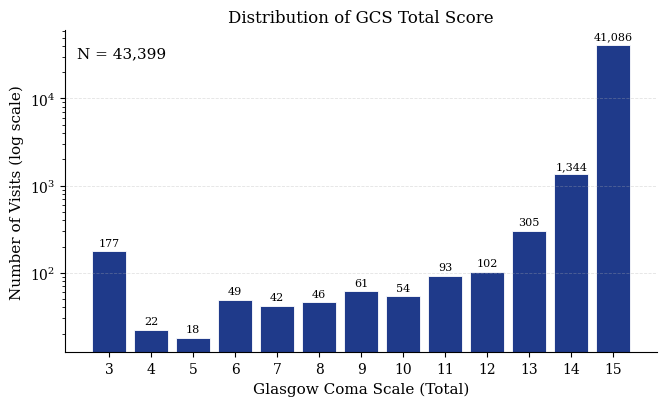

In [6]:
def plot_gcs_logscale(df_cleaned, col="gcs_total"):

    if col not in df_cleaned.columns:
        print(f"Column '{col}' not found.")
        return

    x = df_cleaned[col].dropna().astype(int)

    gcs_vals = np.arange(3, 16)
    counts = x.value_counts().reindex(gcs_vals, fill_value=0).values
    total = counts.sum()

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    fig, ax = plt.subplots(figsize=(6.8, 4.2))

    main_color = "#1F3A8A" 

    ax.bar(
        gcs_vals,
        counts,
        width=0.8,
        color=main_color,
        edgecolor="white",
        linewidth=0.6,
    )

    ax.set_xlabel("Glasgow Coma Scale (Total)")
    ax.set_ylabel("Number of Visits (log scale)")
    ax.set_title("Distribution of GCS Total Score")

    ax.set_xticks(gcs_vals)
    ax.set_yscale("log")

    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.6, alpha=0.35)

    for gcs, c in zip(gcs_vals, counts):
        if c > 0:
            ax.text(
                gcs,
                c * 1.1,
                f"{c:,}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.text(
        0.02, 0.95,
        f"N = {total:,}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

    fig.tight_layout()
    fig.savefig(f"{get_figs_dir()}/eda_gcs_total_distribution.png", dpi=300)
    plt.show()

plot_gcs_logscale(df_cleaned)

## Log Count of Outcome Variables

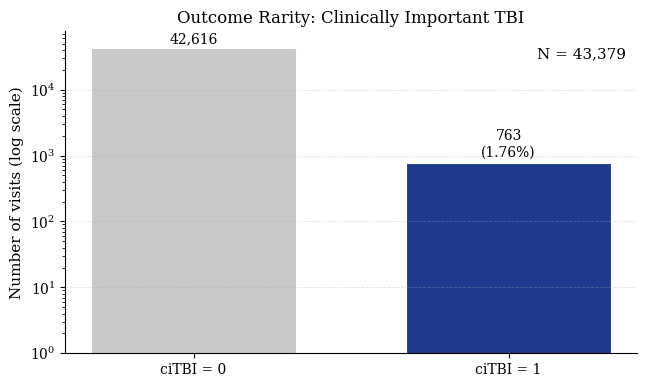

In [7]:
def plot_outcome_rarity_logcount(df_cleaned, y_col="citbi"):
    if y_col not in df_cleaned.columns:
        print(f"Column '{y_col}' not found.")
        return

    y = df_cleaned[y_col].dropna().astype(int)

    # counts for 0/1
    counts = y.value_counts().reindex([0, 1], fill_value=0)
    n0, n1 = int(counts.loc[0]), int(counts.loc[1])
    n = n0 + n1
    pos_rate = n1 / n if n > 0 else np.nan

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    fig, ax = plt.subplots(figsize=(6.6, 4.0))

    # neutral gray for negative; strong but not neon for positive
    neg_color = "#C9C9C9"
    pos_color = "#1F3A8A"

    xs = [0, 1]
    bars = ax.bar(
        xs,
        [n0, n1],
        width=0.65,
        color=[neg_color, pos_color],
        edgecolor="white",
        linewidth=0.8,
    )

    ax.set_yscale("log")
    ax.set_xticks(xs)
    ax.set_xticklabels(["ciTBI = 0", "ciTBI = 1"])
    ax.set_ylabel("Number of visits (log scale)")
    ax.set_title("Outcome Rarity: Clinically Important TBI")

    ax.grid(axis="y", which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.text(0, n0 * 1.08, f"{n0:,}", ha="center", va="bottom", fontsize=10)
    ax.text(
        1,
        n1 * 1.15 if n1 > 0 else 1,
        f"{n1:,}\n({pos_rate*100:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )
    ax.text(
        0.98, 0.95,
        f"N = {n:,}",
        transform=ax.transAxes,
        ha="right",
        va="top"
    )
    ymin = 1
    ymax = max(n0, 1) * 1.8
    ax.set_ylim(ymin, ymax)

    fig.tight_layout()
    fig.savefig(f"{get_figs_dir()}/eda_outcome_rarity_logcount.png", dpi=300)
    plt.show()

plot_outcome_rarity_logcount(df_cleaned)

## Absolute risk of clinically important TBI (ciTBI) by selected clinical indicators

In [8]:
UNKNOWN_CODES = {90, 91, 92}

def summarize_binary_vs_citbi(
    df_cleaned,
    y_col="citbi",
    predictors=None,
):
    if predictors is None:
        predictors = [
            "palpable_skull_fracture",
            "basilar_skull_fracture_signs",
            "posttraumatic_seizure",
            "loss_of_consciousness",
        ]

    rows = []

    for var in predictors:
        if var not in df_cleaned.columns:
            continue

        tmp = df_cleaned[[var, y_col]].copy()

        # remove unknown codes
        for c in [var, y_col]:
            tmp[c] = tmp[c].replace(list(UNKNOWN_CODES), np.nan)

        tmp = tmp.dropna()
        tmp = tmp[tmp[var].isin([0,1]) & tmp[y_col].isin([0,1])]

        if tmp.empty:
            continue

        results = {}

        for val in [1, 0]:
            sub = tmp[tmp[var] == val]
            n = len(sub)
            k = int(sub[y_col].sum())

            rate = k / n if n > 0 else np.nan
            results[val] = (k, n, rate)

        rd = results[1][2] - results[0][2]

        rows.append({
            "Clinical Indicator": var.replace("_", " ").title(),
            "x=1: ciTBI (n/N, %)":
                f'{results[1][0]:,}/{results[1][1]:,} '
                f'({100*results[1][2]:.2f}%)',
            "x=0: ciTBI (n/N, %)":
                f'{results[0][0]:,}/{results[0][1]:,} '
                f'({100*results[0][2]:.2f}%)',
            "Risk Difference (%)":
                f'{100*rd:.2f}'
        })

    table = pd.DataFrame(rows)
    return table

summary_table = summarize_binary_vs_citbi(df_cleaned)
save_table(summary_table, "binary_vs_citbi_summary.csv")
summary_table

,Clinical Indicator,"x=1: ciTBI (n/N, %)","x=0: ciTBI (n/N, %)",Risk Difference (%)
0,Palpable Skull Fracture,84/223 (37.67%),"565/42,076 (1.34%)",36.33
1,Basilar Skull Fracture Signs,126/395 (31.90%),"618/42,540 (1.45%)",30.45
2,Posttraumatic Seizure,61/600 (10.17%),"559/41,867 (1.34%)",8.83
3,Loss Of Consciousness,"345/4,824 (7.15%)","195/34,651 (0.56%)",6.59
